# Bayesian Hierarchical Models in R

## Overview

Bayesian hierarchical models are multilevel models with priors on the group-level parameters themselves (hyperpriors). They implement **partial pooling** — group estimates are shrunk toward the global mean in proportion to how much information each group contains.

**Three pooling strategies:**

| Strategy | What it does | Problem |
|---|---|---|
| **No pooling** | Estimate each group independently | Ignores information sharing; noisy for small groups |
| **Complete pooling** | Ignore group structure entirely | Ignores genuine group differences; biased |
| **Partial pooling** | Groups borrow strength from each other | Optimal; what Bayesian hierarchical models do |

**Shrinkage:** Groups with fewer observations are shrunk more strongly toward the global mean. Groups with many observations retain their own estimate. This is automatic regularisation — it reduces overfitting without cross-validation.

**The key hyperprior insight:** The prior on group-level standard deviation σ_group controls the degree of pooling. σ_group → 0 = complete pooling; σ_group → ∞ = no pooling. The data inform σ_group — the model learns how variable groups are.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(brms)
library(tidybayes)
library(patchwork)

set.seed(42)

# ── Simulate: invertebrate richness across 20 catchments, 8 sites each ────────
n_catchments <- 20
n_per_catch  <- 8
n_total      <- n_catchments * n_per_catch

# Catchment-level true effects
catchment_effects <- rnorm(n_catchments, mean=0, sd=4)

hier_data <- tibble(
  catchment = rep(1:n_catchments, each=n_per_catch),
  nitrate   = rnorm(n_total, 3, 1),
  richness  = round(
    22 +
    rep(catchment_effects, each=n_per_catch) +
    -2 * scale(rnorm(n_total, 3, 1))[,1] +
    rnorm(n_total, 0, 2.5)
  )
) %>%
  mutate(
    catchment = factor(catchment),
    richness  = pmax(richness, 1)
  )

# Three catchments with very few observations (to show shrinkage effect)
sparse_cats <- sample(levels(hier_data$catchment), 3)
hier_data_sparse <- hier_data %>%
  filter(!(catchment %in% sparse_cats) | row_number() <= 2)

cat(sprintf("Total observations: %d across %d catchments\n",
            nrow(hier_data), n_catchments))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'brms' was built under R version 4.4.3"
Loading required package: Rcpp

Loading 'brms' package (version 2.2

Total observations: 160 across 20 catchments


---

## The Three Pooling Models

In [2]:
# ── 1. Complete pooling: ignore catchment structure ───────────────────────────
m_complete <- brm(
  richness ~ nitrate,
  data   = hier_data, family = gaussian(),
  prior  = c(prior(normal(22,10), class=Intercept),
             prior(normal(0,3),   class=b),
             prior(exponential(1), class=sigma)),
  chains=4, iter=2000, warmup=1000, cores=4, seed=42, silent=2
)

# ── 2. No pooling: separate intercept per catchment ───────────────────────────
# Equivalent to lm(richness ~ nitrate + catchment)
m_nopool <- brm(
  richness ~ nitrate + catchment,
  data   = hier_data, family = gaussian(),
  prior  = c(prior(normal(22,10), class=Intercept),
             prior(normal(0,5),   class=b),
             prior(exponential(1), class=sigma)),
  chains=4, iter=2000, warmup=1000, cores=4, seed=42, silent=2
)

# ── 3. Partial pooling: random intercepts (hierarchical) ─────────────────────
# (1|catchment): catchment-level intercepts drawn from N(0, sigma_catchment)
# sigma_catchment is estimated from the data — the hyperprior controls its prior
m_partial <- brm(
  richness ~ nitrate + (1 | catchment),
  data   = hier_data, family = gaussian(),
  prior  = c(
    prior(normal(22,10), class=Intercept),
    prior(normal(0,3),   class=b),
    prior(exponential(1), class=sigma),
    prior(exponential(1), class=sd)  # hyperprior on catchment SD
  ),
  chains=4, iter=3000, warmup=1000, cores=4, seed=42, silent=2
)
print(m_partial)

 Family: gaussian 
  Links: mu = identity 
Formula: richness ~ nitrate + (1 | catchment) 
   Data: hier_data (Number of observations: 160) 
  Draws: 4 chains, each with iter = 3000; warmup = 1000; thin = 1;
         total post-warmup draws = 8000

Multilevel Hyperparameters:
~catchment (Number of levels: 20) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     5.10      0.75     3.87     6.79 1.00     1458     2739

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept    22.37      1.44    19.58    25.21 1.00     1271     2389
nitrate       0.13      0.28    -0.42     0.68 1.00     7902     6181

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma     3.13      0.19     2.79     3.53 1.00     6619     5916

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the p

---

## Visualising Shrinkage

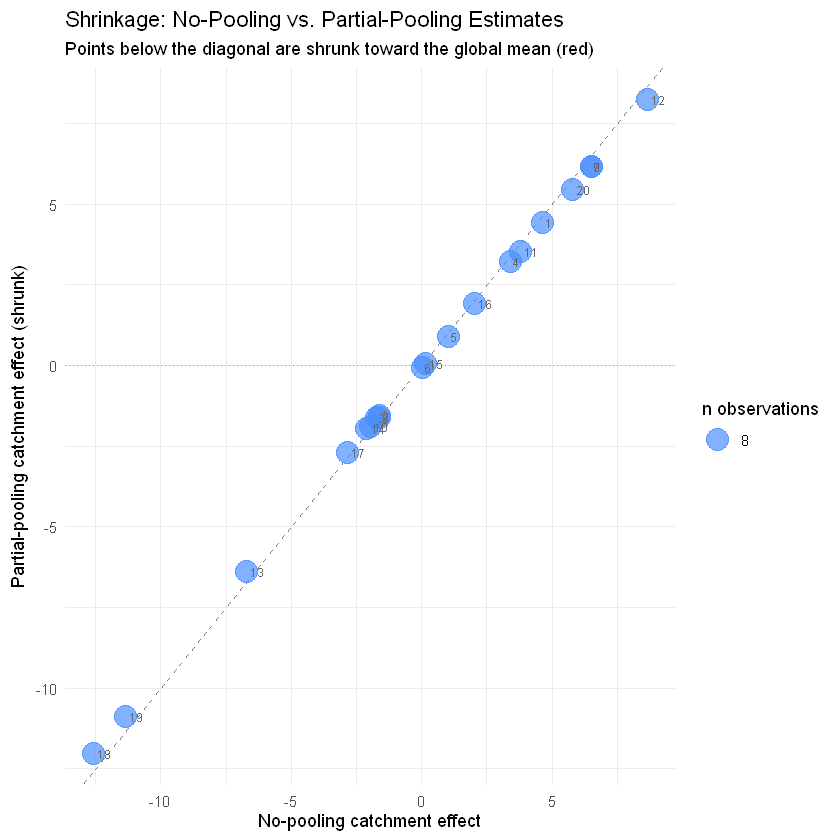

In [3]:
# Extract catchment-level estimates from each model
# No-pooling: direct per-catchment estimates
nopool_means <- hier_data %>%
  group_by(catchment) %>%
  summarise(nopool_mean = mean(richness) - mean(hier_data$richness),
            n_obs = n())

# Partial pooling: random effects
partial_re <- tidybayes::spread_draws(m_partial, r_catchment[catchment, Intercept]) %>%
  group_by(catchment) %>%
  summarise(partial_mean = mean(r_catchment))

# Global mean offset
global_mean <- 0

shrinkage_df <- left_join(
  nopool_means %>% mutate(catchment=as.character(catchment)),
  partial_re   %>% mutate(catchment=as.character(catchment)),
  by="catchment"
)

ggplot(shrinkage_df, aes(x=nopool_mean, y=partial_mean, size=n_obs)) +
  geom_abline(slope=1, intercept=0, linetype="dashed", color="gray50") +
  geom_hline(yintercept=global_mean, linetype="dotted", color="#ff6b6b") +
  geom_point(color="#4a8fff", alpha=0.7) +
  geom_text(aes(label=catchment), hjust=-0.3, size=2.5, color="gray40") +
  scale_size_continuous(range=c(2,8)) +
  labs(title="Shrinkage: No-Pooling vs. Partial-Pooling Estimates",
       subtitle="Points below the diagonal are shrunk toward the global mean (red)",
       x="No-pooling catchment effect",
       y="Partial-pooling catchment effect (shrunk)",
       size="n observations") +
  theme_minimal()
# Points furthest from the diagonal = most shrinkage
# Smaller catchments (smaller bubbles) are shrunk more

---

## Random Slopes Model

Warning message:
"There were 12 divergent transitions after warmup. See
https://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup
to find out why this is a problem and how to eliminate them."
Warning message:
"Examine the pairs() plot to diagnose sampling problems
"
Warning message:
"There were 12 divergent transitions after warmup. Increasing adapt_delta above 0.8 may help. See http://mc-stan.org/misc/warnings.html#divergent-transitions-after-warmup"


 Family: gaussian 
  Links: mu = identity 
Formula: richness ~ nitrate + (1 + nitrate | catchment) 
   Data: hier_data (Number of observations: 160) 
  Draws: 4 chains, each with iter = 3000; warmup = 1000; thin = 1;
         total post-warmup draws = 8000

Multilevel Hyperparameters:
~catchment (Number of levels: 20) 
                       Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(Intercept)              5.07      0.83     3.64     6.88 1.00     2504
sd(nitrate)                0.24      0.19     0.01     0.70 1.00     2056
cor(Intercept,nitrate)    -0.01      0.43    -0.80     0.77 1.00     8519
                       Tail_ESS
sd(Intercept)              2520
sd(nitrate)                1935
cor(Intercept,nitrate)     5279

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept    22.35      1.39    19.60    25.14 1.00     2117     2794
nitrate       0.13      0.28    -0.42     0.67 1.00     8525     5079

Further Distributi

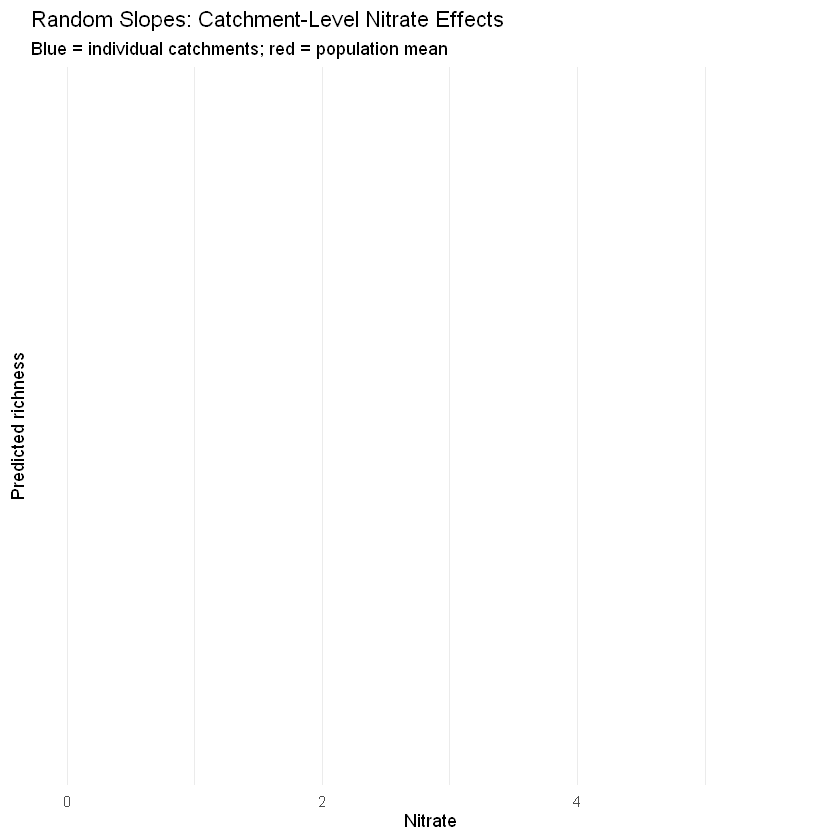

In [4]:
# Allow both intercept and slope to vary by catchment
# (1 + nitrate | catchment): correlated random intercept and slope
m_slopes <- brm(
  richness ~ nitrate + (1 + nitrate | catchment),
  data   = hier_data, family=gaussian(),
  prior  = c(
    prior(normal(22,10),  class=Intercept),
    prior(normal(0,3),    class=b),
    prior(exponential(1), class=sigma),
    prior(exponential(1), class=sd),
    prior(lkj(2),         class=cor)   # LKJ prior on correlation matrix
  ),
  chains=4, iter=3000, warmup=1000, cores=4, seed=42, silent=2
)
print(m_slopes)
# cor(Intercept, nitrate): correlation between catchment intercepts and slopes
# Negative correlation: high-richness catchments show stronger nitrate effect?

# ── Visualise varying slopes ──────────────────────────────────────────────────
catch_draws <- tidybayes::spread_draws(
  m_slopes,
  r_catchment[catchment, term]
) %>%
  group_by(catchment, term) %>%
  summarise(mean_re=mean(r_catchment), .groups="drop") %>%
  pivot_wider(names_from=term, values_from=mean_re) %>%
  mutate(
    intercept = fixef(m_slopes)["Intercept","Estimate"] + Intercept,
    slope     = fixef(m_slopes)["nitrate","Estimate"]   + nitrate
  )

x_range <- range(hier_data$nitrate)
ggplot(catch_draws) +
  geom_abline(aes(intercept=intercept, slope=slope, group=catchment),
              color="#4a8fff", alpha=0.35, linewidth=0.5) +
  geom_abline(intercept=fixef(m_slopes)["Intercept","Estimate"],
              slope=fixef(m_slopes)["nitrate","Estimate"],
              color="#ff6b6b", linewidth=1.5) +
  xlim(x_range) +
  labs(title="Random Slopes: Catchment-Level Nitrate Effects",
       subtitle="Blue = individual catchments; red = population mean",
       x="Nitrate", y="Predicted richness") +
  theme_minimal()

---

## Model Comparison

In [5]:
# Add LOO-CV criterion to each model
m_complete <- add_criterion(m_complete, "loo")
m_partial  <- add_criterion(m_partial,  "loo")
m_slopes   <- add_criterion(m_slopes,   "loo")

# Compare
loo_compare(m_complete, m_partial, m_slopes)
# Models ranked by expected log predictive density (ELPD)
# Higher ELPD = better out-of-sample predictive accuracy
# See model_comparison_waic.ipynb for full treatment

,elpd_diff,se_diff,elpd_loo,se_elpd_loo,p_loo,se_p_loo,looic,se_looic
m_partial,0.0000000,0.0000000,-421.5981,8.107365,19.980675,1.8577578,843.1962,16.21473
m_slopes,-0.8207143,0.1922008,-422.4188,8.048536,20.811306,1.9088681,844.8376,16.09707
m_complete,-100.7927320,10.9277721,-522.3908,8.998304,2.857743,0.3645849,1044.7816,17.99661


---

## Common Pitfalls

**1. Using a wide prior on the group-level SD (σ_group)**  
A half-Cauchy or very wide prior on σ_group allows implausibly large group differences and reduces shrinkage. `exponential(1)` or `half-Normal(0, 1)` on the SD scale appropriate for the outcome is usually better. Always check what σ_group implies in the outcome units.

**2. Confusing partial pooling with complete pooling**  
A common shortcut is to add group as a fixed effect (no-pooling) or to aggregate within groups before fitting (complete pooling). Both discard information. Partial pooling with `(1|group)` in brms is nearly always the correct choice when groups share a common population.

**3. Not examining the random effects variance**  
The estimated σ_group tells you how much groups actually differ. A very small σ_group means groups are nearly identical — complete pooling would have been adequate. A very large σ_group means groups differ dramatically — inspect individual group posteriors.

**4. Fitting random slopes without checking whether slopes genuinely vary**  
Random slopes add complexity. Use LOO-CV to check whether they improve predictive accuracy. If the correlation between random intercepts and slopes is estimated with very wide uncertainty, there is insufficient data to estimate it — use `(1 + nitrate || catchment)` (double bar: uncorrelated) or drop random slopes.

**5. Not accounting for hierarchical structure in study design**  
If sites are nested within catchments and observations are nested within sites, both levels need to be modelled. Ignoring a level of nesting leads to pseudoreplication and incorrect standard errors — even in a Bayesian model.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*